In [2]:
"""SD3.5-M Prompt-based Image Editing

Based on: "Exploring Multimodal Diffusion Transformers for Enhanced Prompt-based Image Editing"
"""

import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusion3Pipeline

import sys
sys.path.append("..")
from utils import (
    register_qkv_control,
    create_qkv_controller,
    p2p_callback,
    TOP5_BLOCKS,
)

pipe = StableDiffusion3Pipeline.from_pretrained(
    "stabilityai/stable-diffusion-3.5-medium", torch_dtype=torch.bfloat16
).to("cuda")

/opt/conda/envs/exp-mmdit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 9/9 [00:01<00:00,  4.58it/s]


Registered 24 attention processors (SDPA: True).


100%|██████████| 28/28 [00:17<00:00,  1.56it/s]


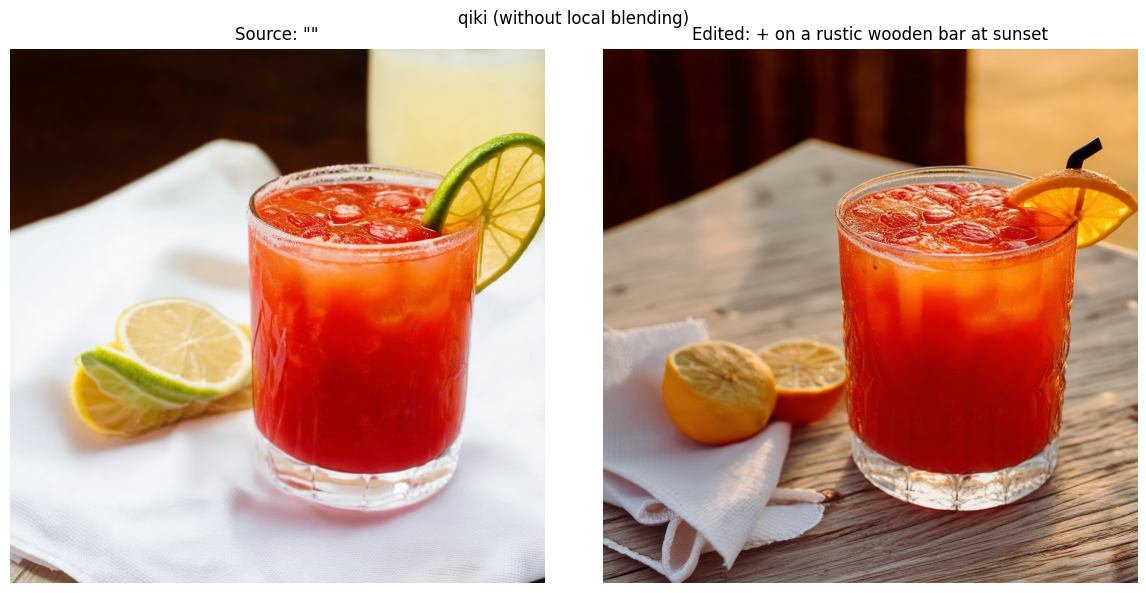

In [3]:
# Basic Replace (qiki) - without local blending

prompts = [
    "a bloody mary cocktail next to a napkin",
    "a bloody mary cocktail next to a napkin on a rustic wooden bar at sunset",
]

height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2, pipe.tokenizer_3]

controller = create_qkv_controller(
    pipeline_type="sd3",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    t5_max_seq_len=256,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=7.0,
    height=height,
    width=width,
    max_sequence_length=256,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: \"\"")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: + on a rustic wooden bar at sunset")
ax[1].axis("off")
plt.suptitle("qiki (without local blending)")
plt.tight_layout()

Registered 24 attention processors (SDPA: True).


100%|██████████| 28/28 [00:18<00:00,  1.53it/s]


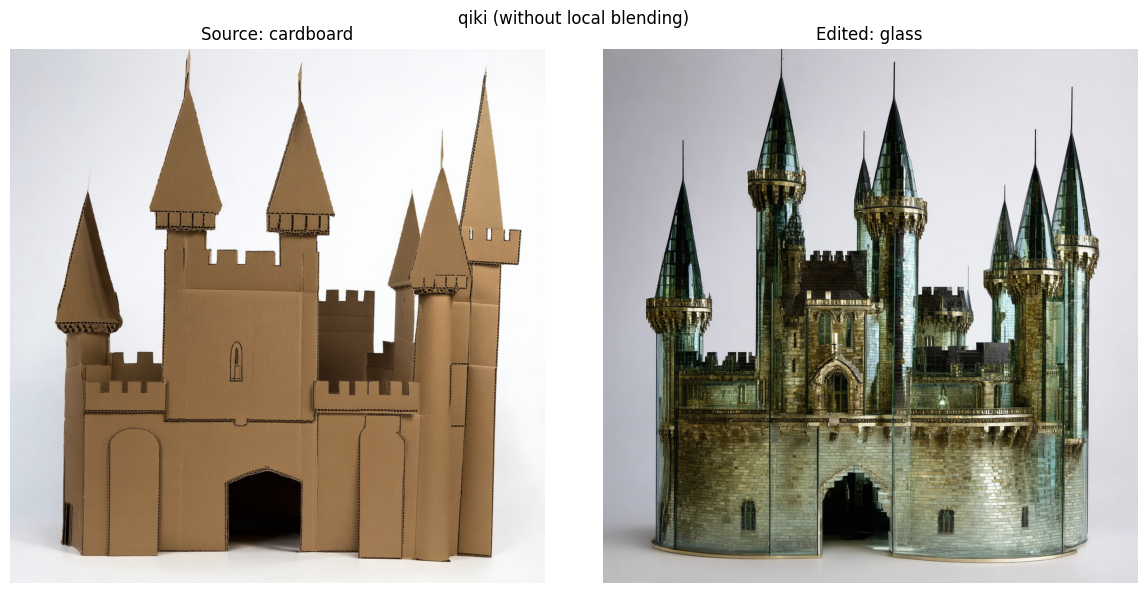

In [4]:
# Replace (qiki) - without local blending

prompts = ["A castle made of cardboard.", "A castle made of glass."]

height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2, pipe.tokenizer_3]

controller = create_qkv_controller(
    pipeline_type="sd3",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    t5_max_seq_len=256,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=7.0,
    height=height,
    width=width,
    max_sequence_length=256,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: cardboard")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: glass")
ax[1].axis("off")
plt.suptitle("qiki (without local blending)")
plt.tight_layout()

Registered 24 attention processors (SDPA: True).


100%|██████████| 28/28 [00:19<00:00,  1.45it/s]


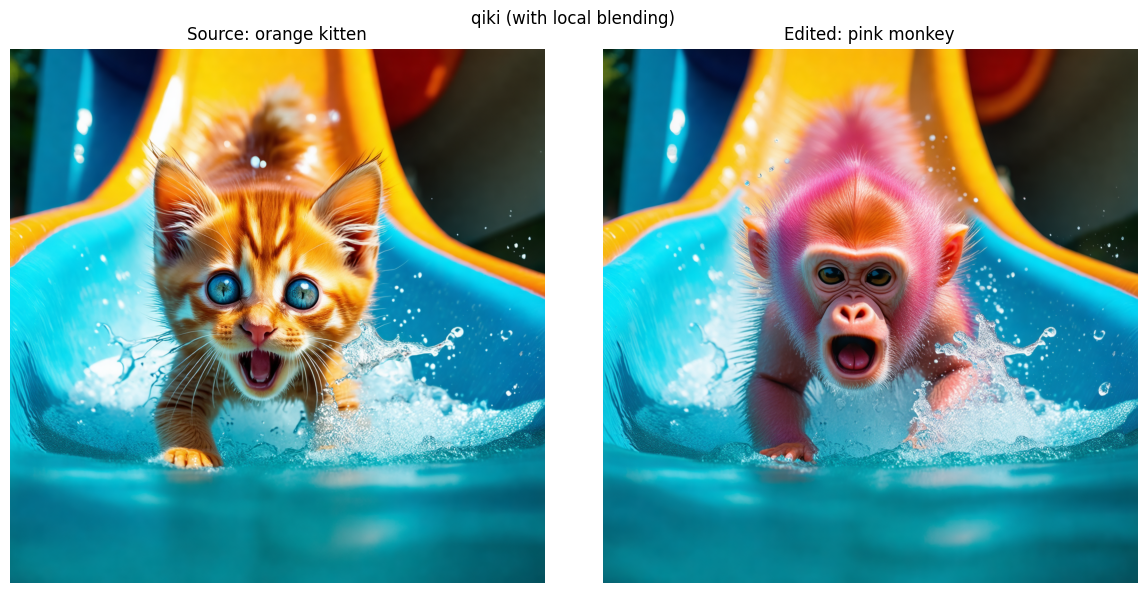

In [5]:
# Replace (qiki) - with local blending

prompts = [
    "cute orange kitten sliding down an aqua slide. happy excited. 16mm lens in front. we see his excitement and scared in the eye. vibrant colors. water splashing on the lens",
    "cute pink monkey sliding down an aqua slide. happy excited. 16mm lens in front. we see his excitement and scared in the eye. vibrant colors. water splashing on the lens",
]
height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2, pipe.tokenizer_3]

controller = create_qkv_controller(
    pipeline_type="sd3",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    local_blend_words=["orange kitten", "pink monkey"],
    local_blend_threshold=0.2,
    aggregate_blocks=TOP5_BLOCKS["sd3.5-m"],
    t5_max_seq_len=256,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=7.0,
    height=height,
    width=width,
    max_sequence_length=256,
    generator=[torch.Generator().manual_seed(8347893), torch.Generator().manual_seed(8347893)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: orange kitten")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: pink monkey")
ax[1].axis("off")
plt.suptitle("qiki (with local blending)")
plt.tight_layout()

In [6]:
del pipe
torch.cuda.empty_cache()
print("Done!")

Done!
